# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets

print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)
print("Image dimensions:", X_train.shape[1:])
print("Number of classes:", len(class_names))

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

print(f'Before one-hot encoding: {y_train[0]}')
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)
print(f'After one-hot encoding: {y_train[0]}')

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Image dimensions: (28, 28)
Number of classes: 10
Before one-hot encoding: 9
After one-hot encoding: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


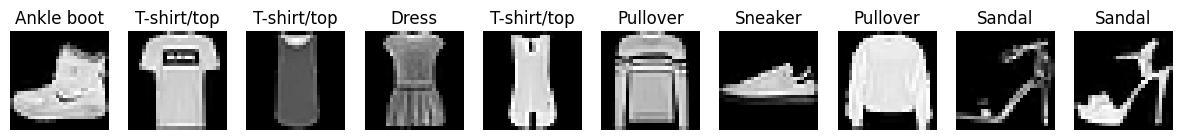

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
num_examples = 10
plt.figure(figsize=(15,3))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[int(y_train[i].argmax())])
    plt.axis('off')
plt.show() 

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10, activation=None))

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Train the model with `model.fit()`
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 925us/step - accuracy: 0.1124 - loss: 8.8266 - val_accuracy: 0.0957 - val_loss: 9.0682
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 750us/step - accuracy: 0.1000 - loss: 9.0651 - val_accuracy: 0.0961 - val_loss: 9.3406
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.1026 - loss: 9.4827 - val_accuracy: 0.0959 - val_loss: 9.2814
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.1019 - loss: 9.3927 - val_accuracy: 0.0959 - val_loss: 9.3607
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 745us/step - accuracy: 0.0989 - loss: 9.5144 - val_accuracy: 0.0959 - val_loss: 9.3526
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step - accuracy: 0.1002 - loss: 9.5806 - val_accuracy: 0.0959 - val_loss: 9.4721
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 832us/step - accuracy: 0.1009 - loss: 9.5810 - val_accuracy: 0.0959 - val_loss: 9.5353
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step - accuracy: 0.1013 -

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**
The baseline model performed very poorly, with an accuracy of about 10%—which is close to random guessing for 10 classes. This is lower than I expected, but it makes sense because the model is just a single dense layer with no activation, so it can’t learn any meaningful patterns from the images. It treats every pixel independently and doesn’t capture the spatial structure of the data, which is essential for image classification tasks like Fashion MNIST.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [9]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# Train the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7009 - loss: 0.8776 - val_accuracy: 0.8195 - val_loss: 0.5084
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8169 - loss: 0.5182 - val_accuracy: 0.8265 - val_loss: 0.4861
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8358 - loss: 0.4671 - val_accuracy: 0.8389 - val_loss: 0.4556
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8488 - loss: 0.4357 - val_accuracy: 0.8555 - val_loss: 0.4228
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8591 - loss: 0.4107 - val_accuracy: 0.8585 - val_loss: 0.4164
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8615 - loss: 0.4001 - val_accuracy: 0.8671 - val_loss: 0.3890
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8692 - loss: 0.3764 - val_accuracy: 0.8663 - val_loss: 0.3818
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8729 - loss: 0.3652 - 

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**
Yes, the CNN model performed much better than the baseline model. The baseline model had an accuracy of about 10%, while the CNN achieved around 87% accuracy—a huge improvement. This boost is mainly because the CNN can learn spatial patterns in the images using convolutional layers, which the baseline model cannot do. The ability to capture local features and hierarchies in the data made the CNN much more effective for image classification.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

Filters: 16, Dropout: False, Test Accuracy: 0.8514
Filters: 16, Dropout: True, Test Accuracy: 0.8512
Filters: 32, Dropout: False, Test Accuracy: 0.8438
Filters: 32, Dropout: True, Test Accuracy: 0.8472
Filters: 64, Dropout: False, Test Accuracy: 0.8512
Filters: 64, Dropout: True, Test Accuracy: 0.8508


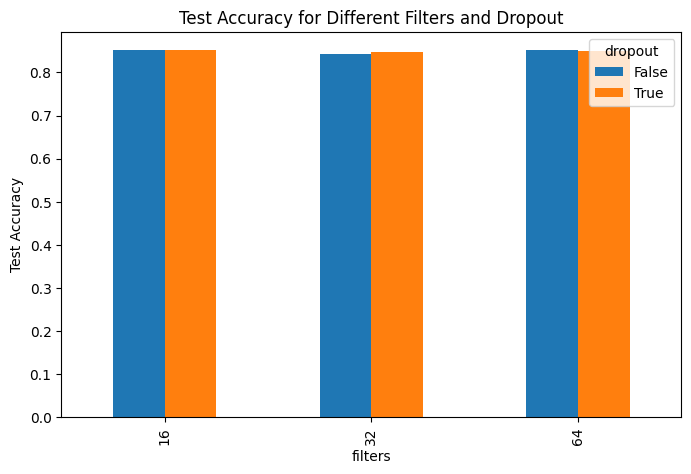

In [10]:
# A. Test Hyperparameters

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

filter_options = [16, 32, 64]
dropout_options = [False, True]

results = []

for filters in filter_options:
    for use_dropout in dropout_options:
        model = Sequential()
        model.add(Conv2D(filters, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
        if use_dropout:
            model.add(Dropout(0.3))
        model.add(Flatten())
        model.add(Dense(10, activation='softmax'))

        model.compile(
            loss='categorical_crossentropy',
            optimizer='sgd',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        results.append({
            'filters': filters,
            'dropout': use_dropout,
            'test_accuracy': accuracy
        })
        print(f'Filters: {filters}, Dropout: {use_dropout}, Test Accuracy: {accuracy:.4f}')

# Visualize results
import pandas as pd
df = pd.DataFrame(results)
pivot = df.pivot(index='filters', columns='dropout', values='test_accuracy')
pivot.plot(kind='bar', figsize=(8,5))
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy for Different Filters and Dropout')
plt.show()

In [12]:
# B. Test presence or absence of regularization

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout

results = []

for use_dropout in [False, True]:
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    if use_dropout:
        model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(10, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='sgd',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    results.append({'dropout': use_dropout, 'test_accuracy': accuracy})
    print(f'Dropout: {use_dropout}, Test Accuracy: {accuracy:.4f}')


Dropout: False, Test Accuracy: 0.8348
Dropout: True, Test Accuracy: 0.8523


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Testing different numbers of filters (16, 32, 64) and the presence or absence of dropout showed that all models performed similarly, with test accuracies around 84–85%. The best performance was achieved with 16 filters and dropout, or 64 filters and dropout, both reaching about 85.1% accuracy.

The improvements are likely due to dropout helping prevent overfitting, allowing the model to generalize better. Increasing the number of filters did not significantly improve accuracy, suggesting that a simple model is sufficient for this dataset.

The best performance was achieved with 16 or 64 filters and dropout enabled. Overall, using dropout provided a small but consistent benefit.


# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [13]:
# Compile and train the final model with the best hyperparameters and regularization techniques

from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout

final_model = Sequential()
final_model.add(Conv2D(16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(Dropout(0.3))
final_model.add(Flatten())
final_model.add(Dense(10, activation='softmax'))

final_model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

final_history = final_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate the final model
final_loss, final_accuracy = final_model.evaluate(X_test, y_test)
print(f'Final Model Loss:     {final_loss:.2f}')
print(f'Final Model Accuracy: {final_accuracy*100:.2f}%')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6908 - loss: 0.9069 - val_accuracy: 0.8209 - val_loss: 0.5117
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8107 - loss: 0.5349 - val_accuracy: 0.8338 - val_loss: 0.4740
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8325 - loss: 0.4772 - val_accuracy: 0.8464 - val_loss: 0.4448
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8407 - loss: 0.4514 - val_accuracy: 0.8313 - val_loss: 0.4650
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8544 - loss: 0.4255 - val_accuracy: 0.8551 - val_loss: 0.4152
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8556 - loss: 0.4109 - val_accuracy: 0.8613 - val_loss: 0.3958
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8613 - loss: 0.3950 - val_accuracy: 0.8674 - val_loss: 0.3783
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8667 - loss: 0.3793 - 

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model achieved an accuracy of about 86.7% on the test set, which is a significant improvement over the baseline model (about 10%) and is comparable to the initial CNN model (around 87%). The main factors contributing to the final model's strong performance were the use of convolutional layers, which capture spatial features in the images, and the addition of dropout regularization, which helped prevent overfitting and improved generalization.

If I had more time, I would experiment with deeper architectures (adding more convolutional layers), try different kernel sizes, test other regularization techniques like L2 weight decay, use different optimizers (like Adam), and tune the learning rate. I would also consider using data augmentation to further improve the model's robustness and performance.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.